Batarya Ömür Tahmini Projesi (Battery Aging Prediction Project)

Veri analizi için model oluşturma ve testler yapma (Building the model for data analysis and testing).

1. Gerekli kütüphaneleri koda ekledim (Added essential libraries to the code).

In [2]:
#Got the essential libraries
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

2. Analize hazır veriyi h5 dosyasından alıp, bu veriler ile bir Elastic Net lineer regresyon modeli eğittim,hiperparametre optimizasyonu yaptım ve test ettim
(Got the data ready for analysis from the h5 file, trained an Elastic Net lineer regression model with this data, did hyperparameter optimization and tested it).

In [ ]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined error rates matrices for model statistics
fold_rmse_scores = []
fold_mae_scores = []

fold_rmse_opt_scores = []
fold_mae_opt_scores = []

#Opened the h5 file with features and target data, printed the feature names
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    first_battery = list(h5f.keys())[0]
    feature_names = h5f[first_battery]['Features'].attrs['Names']
    print("Features Used in the Model:")
    print(feature_names)
    
    #Got the features and target data, and grouped them under same battery name
    batteries = list(h5f.keys())
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combined all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):
        print(f"--- FOLD {fold+1} ---")

        #Defined the Features and Target for train and test datasets
        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built a base model with pipeline
        base_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42))
        ])

        #Trained the base model for future comparison
        print("Elastic Net is training...")
        model = base_pipeline.fit(X_train, y_train)

        #Built another model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',ElasticNet(random_state=42))
        ])

        #Set hyperparameter options for grid search
        param_grid = {
            'model__alpha': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
            'model__l1_ratio': [0.01]
        }

        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Trained the optimized model
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model_opt = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        
        #Inspected the feature coefficients
        coefficients = model[-1].coef_
        opt_coeffficients = model_opt[-1].coef_
        print("Feature Coefficients           :", np.round(coefficients, 4))
        print("Feature Coefficients(Optimized):", np.round(opt_coeffficients, 4))
        
        #Did the prediction and calculated the error rates
        y_prediction = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
        mae = mean_absolute_error(y_test, y_prediction)

        y_prediction_opt = model_opt.predict(X_test)
        rmse_opt = np.sqrt(mean_squared_error(y_test, y_prediction_opt))
        mae_opt = mean_absolute_error(y_test, y_prediction_opt)
        
        #Added error rates to the matrices
        fold_rmse_scores.append(rmse)
        fold_mae_scores.append(mae)

        fold_rmse_opt_scores.append(rmse_opt)
        fold_mae_opt_scores.append(mae_opt)
        
        print(f"RMSE           : {rmse:.4f} | MAE           : {mae:.4f}")
        print(f"RMSE(Optimized): {rmse_opt:.4f} | MAE(Optimized): {mae_opt:.4f}")

    #Printed the results
    print("\n" + "="*40)
    print("ELASTIC NET 5-FOLD ERROR RATE RESULTS:")
    print(f"Mean RMSE           : {np.mean(fold_rmse_scores):.4f}")
    print(f"Mean MAE            : {np.mean(fold_mae_scores):.4f}")
    print(f"Mean RMSE(Optimized): {np.mean(fold_rmse_opt_scores):.4f}")
    print(f"Mean MAE(Optimized) : {np.mean(fold_mae_opt_scores):.4f}")

Features Used in the Model:
['Internal_Resistance' 'Temperature_Variance' 'dQ/dV_Kurtosis'
 'dQ/dV_Skewness' 'dQ/dV_Peakheight' 'dQ/dV_Variance_log']
--- FOLD 1 ---
Elastic Net is training...
Best parameters: {'model__alpha': 1e-06, 'model__l1_ratio': 0.01}
Feature Coefficients           : [-0.      0.     -0.      0.      0.      0.4369]
Feature Coefficients(Optimized): [ 0.0278  0.0078  0.1999  0.3854 -0.4875  0.7416]
RMSE           : 0.0156 | MAE           : 0.0127
RMSE(Optimized): 0.0086 | MAE(Optimized): 0.0060
--- FOLD 2 ---
Elastic Net is training...
Best parameters: {'model__alpha': 1e-06, 'model__l1_ratio': 0.01}
Feature Coefficients           : [-0.     -0.     -0.      0.      0.      0.4365]
Feature Coefficients(Optimized): [ 0.0244  0.0052  0.2271  0.4133 -0.5082  0.7474]
RMSE           : 0.0153 | MAE           : 0.0122
RMSE(Optimized): 0.0074 | MAE(Optimized): 0.0054
--- FOLD 3 ---
Elastic Net is training...
Best parameters: {'model__alpha': 1e-06, 'model__l1_ratio': 0.01

3. Modelin optimizasyon sonrası son train-test konfigürasyonunun sonuçlarını kullanarak grafikler çizdirdim
(Plotted graphs with the results from last train-test configuration of the model after optimization).

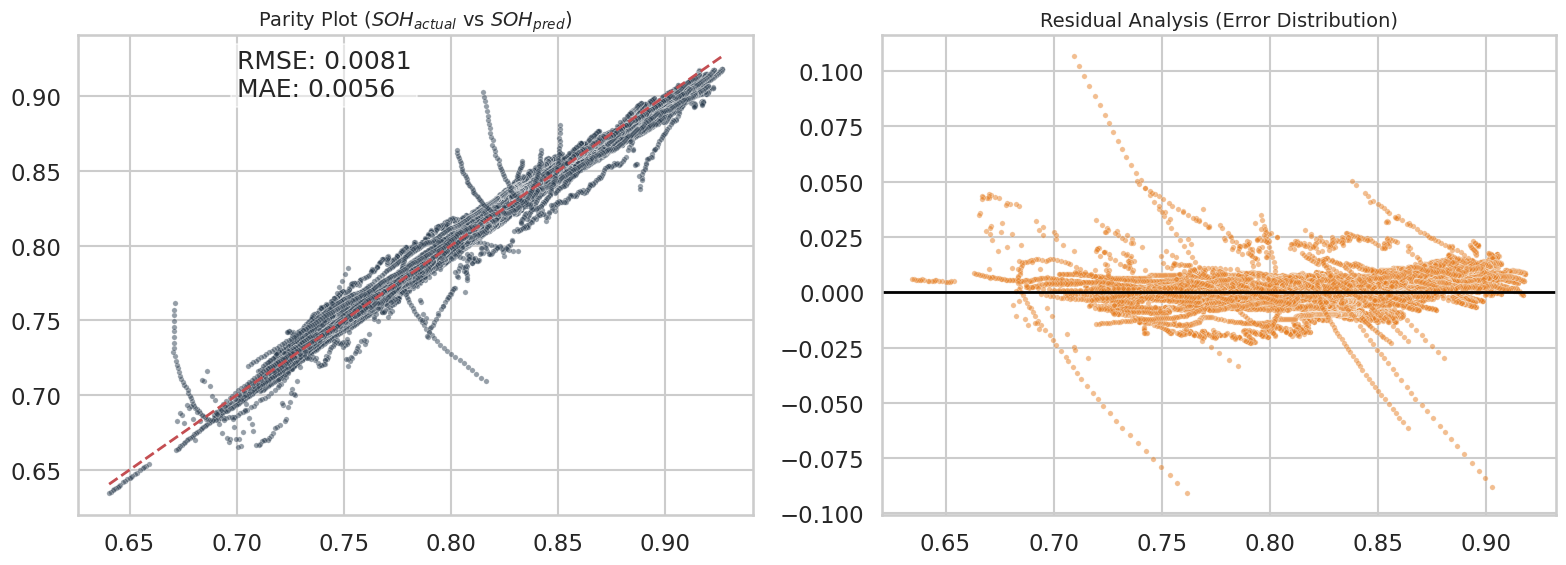

In [4]:
#Set the seaborn theme
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plotted the parity(Real vs Predicted)
sns.scatterplot(x=y_test, y=y_prediction_opt, alpha=0.5, color="#2c3e50", s=15, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(r'Parity Plot ($SOH_{actual}$ vs $SOH_{pred}$)', fontsize=14)


#Plotted the residuals ()
residuals = y_test - y_prediction_opt
sns.scatterplot(x=y_prediction_opt, y=residuals, alpha=0.5, color="#e67e22", s=15, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='-', lw=2)
axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14)
axes[0].text(0.7, 0.9, f'RMSE: {rmse_opt:.4f}\nMAE: {mae_opt:.4f}', bbox=dict(facecolor='white', alpha=0.5))

#Printed the graph
plt.tight_layout()
plt.show()

4. Hiperparametre optimizasyonu öncesi ve sonrası Elastic Net modelinin katsayılarını karşılaştırdım
(Compared the coefficients of the Elastic Net model for before-after hyperparameter optimization)

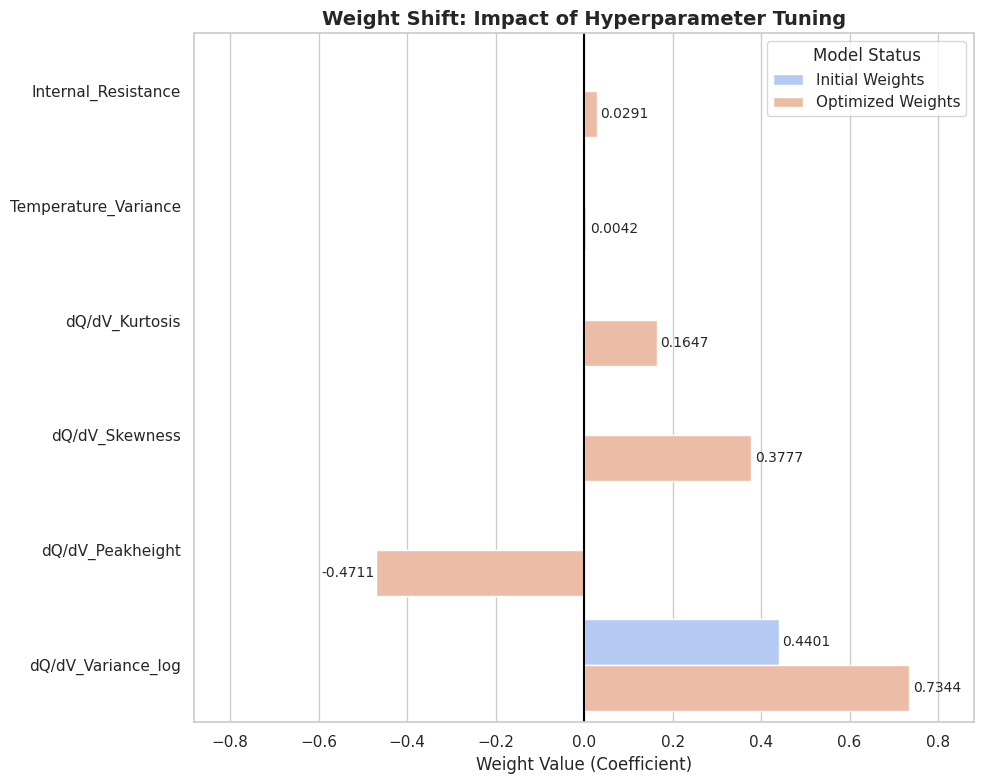

In [5]:
#Defined the coefficient data for features
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Initial Weights': coefficients,
    'Optimized Weights': opt_coeffficients
}).melt(id_vars='Feature', var_name='Model Status', value_name='Weight Value')

#Defined the size of the plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

#Plotted a bar graph
ax = sns.barplot(
    data=coef_df, 
    y='Feature',      
    x='Weight Value', 
    hue='Model Status', 
    palette='coolwarm'
)

#Adjusted the graph for small values
max_val = coef_df['Weight Value'].abs().max()
plt.xlim(-max_val * 1.2, max_val * 1.2) 

#Set up the title and labels
plt.title('Weight Shift: Impact of Hyperparameter Tuning', fontweight='bold', fontsize=14)
plt.xlabel('Weight Value (Coefficient)', fontsize=12)
plt.ylabel('') 
plt.axvline(0, color='black', lw=1.5) 

#Wrote the coefficient values on the graph
for p in ax.patches:
    width = p.get_width()
    if abs(width) > 0:
        ax.annotate(f'{width:.4f}', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha = 'center', va = 'center', 
                    xytext = (20 if width > 0 else -20, 0), 
                    textcoords = 'offset points',
                    fontsize=10)

#Printed the graph
plt.tight_layout()
plt.show()

5. Modelin batalyalar özelinde Elastic Net modelinin hata oranlarını hesapladım, en yüksek ve en düşük hata oranına sahip piller için model performansını grafiklerle karşılaştırdım
(Calculated the error rates or Elastic Net model for individual batteries, compared the model performance with graphics on batteries with highest and lowest error rates).

Rank  | Best Batteries (Low Error)         | Worst Batteries (High Error)  
---------------------------------------------------------------------------
#1    | FastCharge_000015_CH12_st (0.0018) | FastCharge_000017_CH46_st (0.0261)
#2    | FastCharge_000015_CH28_st (0.0020) | FastCharge_000052_CH41_st (0.0239)
#3    | FastCharge_000012_CH37_st (0.0022) | FastCharge_000049_CH37_st (0.0216)
#4    | FastCharge_000001_CH38_st (0.0024) | FastCharge_000024_CH45_st (0.0198)
#5    | FastCharge_000042_CH36_st (0.0026) | FastCharge_000043_CH16_st (0.0184)
#6    | FastCharge_000012_CH45_st (0.0027) | FastCharge_000035_CH12_st (0.0183)
#7    | FastCharge_000006_CH19_st (0.0027) | FastCharge_000021_CH28_st (0.0177)
#8    | FastCharge_000050_CH40_st (0.0028) | FastCharge_000023_CH37_st (0.0176)
#9    | FastCharge_000012_CH13_st (0.0028) | FastCharge_000004_CH3_str (0.0174)
#10   | FastCharge_000013_CH13_st (0.0028) | FastCharge_000038_CH13_st (0.0174)


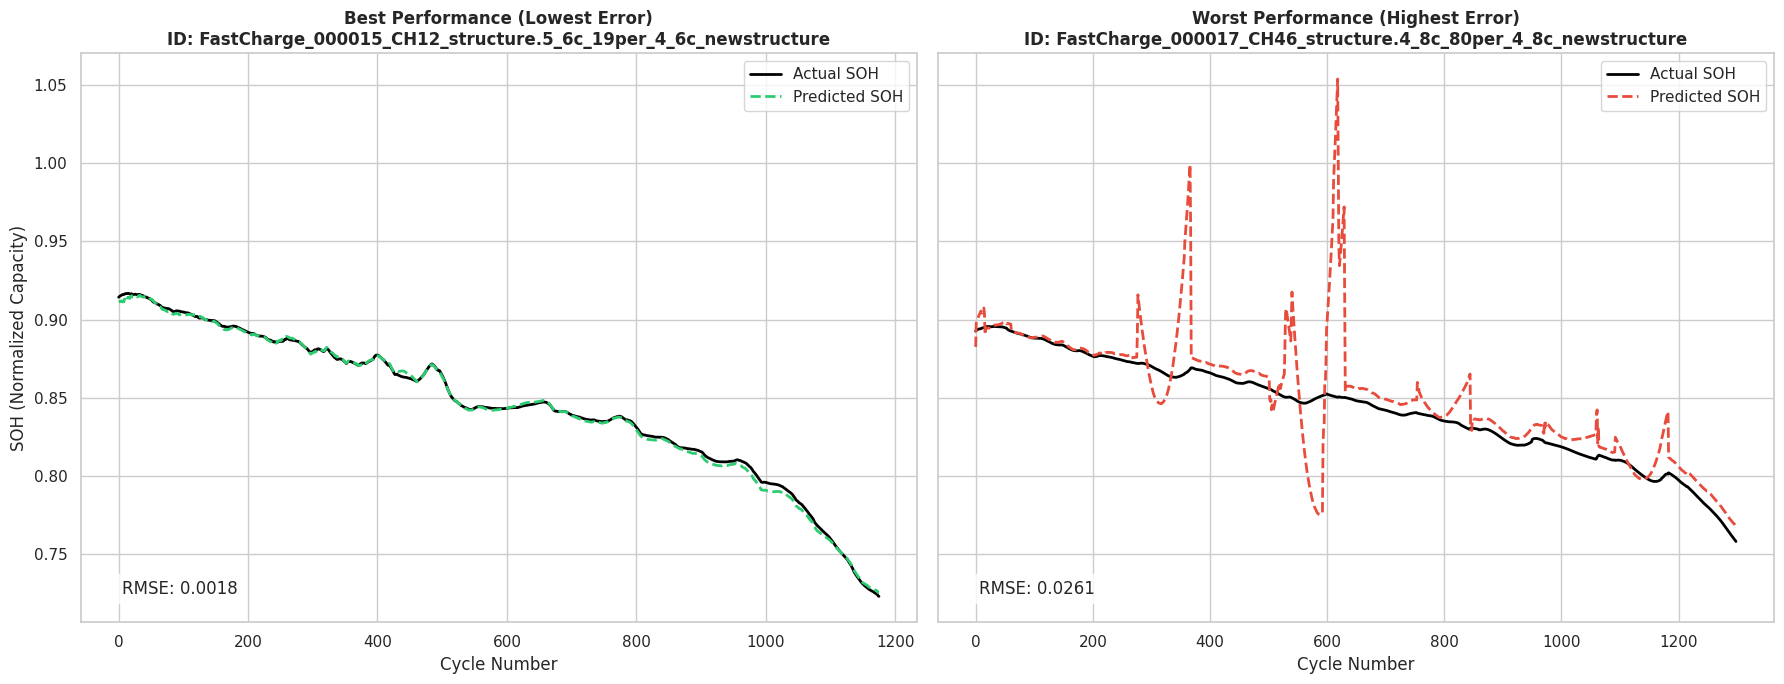

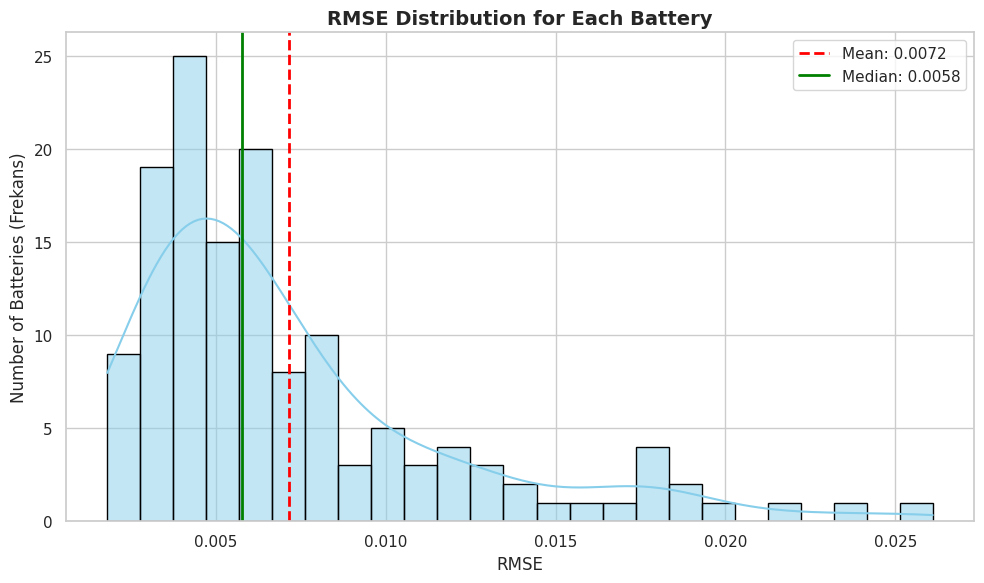

In [6]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined a dictionary to save individual battery errors and results
battery_errors = {}
battery_results = {}

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    batteries = list(h5f.keys())

    #Got the features and target data, and grouped them under same battery name
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combined all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)


    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):

        #Defined the Features and Target for train and test datasets
        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built another model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',ElasticNet(random_state=42))
        ])

        #Set hyperparameter options for grid search
        param_grid = {
            'model__alpha': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
            'model__l1_ratio': [0.01]
        }


        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Built athe model with optimized hyperparameters and trained it
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model = grid_search.best_estimator_

        #Did the prediction and measured error rates
        y_prediction = model.predict(X_test)
        
        #Found the unique batteries to inspect their error rates 
        test_groups = Groups[test_index]
        unique_batteries = np.unique(test_groups)
        for bat_idx in unique_batteries:
            mask = (test_groups == bat_idx)
            bat_y_true = y_test[mask]
            bat_y_pred = y_prediction[mask]
            bat_rmse = np.sqrt(mean_squared_error(bat_y_true, bat_y_pred))
            bat_name = batteries[bat_idx]
            
            #Saved the values and error rates for plotting
            battery_errors[bat_name] = bat_rmse
            battery_results[bat_name] = {
                'true': bat_y_true,
                'pred': bat_y_pred,
                'rmse': bat_rmse
            }

#Sorted the error rates and got the top 10 and bottom 10 error rates
sorted_errors = sorted(battery_errors.items(), key=lambda item: item[1])
best_10 = sorted_errors[:10]       # En düşük hatalı ilk 10
worst_10 = sorted_errors[-10:][::-1] # En yüksek hatalı son 10 (ters çevrilmiş)

#Printed the results
print(f"{'Rank':<5} | {'Best Batteries (Low Error)':<30}     | {'Worst Batteries (High Error)':<30}")
print("-" * 75)
for i in range(10):
    b_name, b_err = best_10[i]
    w_name, w_err = worst_10[i]
    print(f"#{i+1:<4} | {b_name[:25]:<25} ({b_err:.4f}) | {w_name[:25]:<25} ({w_err:.4f})")

#Found the worst and best resulted batteries
best_bat_name = best_10[0][0]
worst_bat_name = worst_10[0][0]

#Started poltting the results for both of them for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_style("whitegrid")

#Set up the graph,title,axis
for i, (b_name, title, color) in enumerate([
    (best_bat_name, "Best Performance (Lowest Error)", "#2ecc71"),
    (worst_bat_name, "Worst Performance (Highest Error)", "#e74c3c")
]):
    data = battery_results[b_name]
    cycles = range(len(data['true']))
    
    axes[i].plot(cycles, data['true'], label='Actual SOH', color='black', lw=2)
    axes[i].plot(cycles, data['pred'], label='Predicted SOH', color=color, linestyle='--', lw=2)
    
    axes[i].set_title(f"{title}\nID: {b_name}", fontweight='bold')
    axes[i].set_xlabel('Cycle Number')
    axes[i].legend()
    axes[i].text(0.05, 0.05, f"RMSE: {data['rmse']:.4f}", transform=axes[i].transAxes, 
                 bbox=dict(facecolor='white', alpha=0.8))

axes[0].set_ylabel('SOH (Normalized Capacity)')

#Printed the graph
plt.tight_layout()
plt.show()

#Defined an error list
errors_list = list(battery_errors.values())

#Defined the figure and wrote histogram with density curve (KDE)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(errors_list, bins=25, kde=True, color='skyblue', edgecolor='black')

#Added statistical values (Mean and Median)
mean_val = np.mean(errors_list)
median_val = np.median(errors_list)

#Set up the graph,title,axis
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.4f}')

plt.title('RMSE Distribution for Each Battery', fontsize=14, fontweight='bold')
plt.xlabel('RMSE', fontsize=12)
plt.ylabel('Number of Batteries (Frekans)', fontsize=12)
plt.legend()

#Printed the graph
plt.tight_layout()
plt.show()

6. Aynı veri ile bir Random Forest regresyon modeli eğittim, bu modele de hiperparametre optimizsayonu yaptım ve test ettim
(Trained a Random Forest regressor with same data, did hyperparameter optimization for this model as well and tested it).

In [10]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined error rates for model statistics
fold_rmse_scores = []
fold_mae_scores = []

fold_rmse_opt_scores = []
fold_mae_opt_scores = []

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    batteries = list(h5f.keys())

    #Got the features and target data, and grouped them under same battery name
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combining all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):
        print(f"--- FOLD {fold+1} ---")

        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built a base model with pipeline
        base_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
        ])

        #Trained the base model for future comparison
        print("Random Forest is Training (This process might take couple minutes)...")
        model = base_pipeline.fit(X_train, y_train)

        #Built another model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',RandomForestRegressor(random_state=42, n_jobs=-1))
        ])
        
        #Set hyperparameter options for grid search
        param_grid = {
            'model__n_estimators': [200, 300, 500],
            'model__max_depth': [15, 25],
            'model__min_samples_split' : [2],
            'model__min_samples_leaf': [6, 9],
            'model__max_features': ['sqrt']
        }

        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Built another model with optimized hyperparameters and trained it for future comparison
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model_opt = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        
        #Inspected the feature importances
        feature_importances = model[-1].feature_importances_
        opt_feature_importances = model_opt[-1].feature_importances_
        print("Feature Importances:", np.round(feature_importances, 4))
        print("Feature Importances:", np.round(opt_feature_importances, 4))

        #Did the prediction and calculated the error rates
        y_prediction = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
        mae = mean_absolute_error(y_test, y_prediction)

        y_prediction_opt = model_opt.predict(X_test)
        rmse_opt = np.sqrt(mean_squared_error(y_test, y_prediction_opt))
        mae_opt = mean_absolute_error(y_test, y_prediction_opt)
        
        #Added error rates to the matrices
        fold_rmse_scores.append(rmse)
        fold_mae_scores.append(mae)

        fold_rmse_opt_scores.append(rmse_opt)
        fold_mae_opt_scores.append(mae_opt)
        
        print(f"RMSE           : {rmse:.4f} | MAE           : {mae:.4f}")
        print(f"RMSE(Optimized): {rmse_opt:.4f} | MAE(Optimized): {mae_opt:.4f}")
        
    #Printed the results
    print("\n" + "="*50)
    print("RANDOM FOREST REGRESSOR 5-FOLD ERROR RATE RESULTS:")
    print(f"Mean RMSE           : {np.mean(fold_rmse_scores):.4f}")
    print(f"Mean MAE            : {np.mean(fold_mae_scores):.4f}")
    print(f"Mean RMSE(Optimized): {np.mean(fold_rmse_opt_scores):.4f}")
    print(f"Mean MAE(Optimized) : {np.mean(fold_mae_opt_scores):.4f}")

--- FOLD 1 ---
Random Forest is Training (This process might take couple minutes)...
Best parameters: {'model__max_depth': 25, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 6, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Feature Importances: [0.0049 0.0021 0.0067 0.0468 0.0155 0.924 ]
Feature Importances: [0.0525 0.007  0.0334 0.0485 0.3757 0.483 ]
RMSE           : 0.0058 | MAE           : 0.0039
RMSE(Optimized): 0.0054 | MAE(Optimized): 0.0037
--- FOLD 2 ---
Random Forest is Training (This process might take couple minutes)...
Best parameters: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 6, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Feature Importances: [0.0051 0.0021 0.0117 0.0488 0.0104 0.9219]
Feature Importances: [0.0521 0.0076 0.032  0.0447 0.3686 0.495 ]
RMSE           : 0.0058 | MAE           : 0.0036
RMSE(Optimized): 0.0054 | MAE(Optimized): 0.0034
--- FOLD 3 ---
Random Forest is Training (This pro

7. Bu modelin de optimizasyon sonrası son train-test konfigürasyonunun sonuçlarını kullanarak grafikler çizdirdim
(Plotted graphs with the results from last train-test configuration of this model as well after optimization).

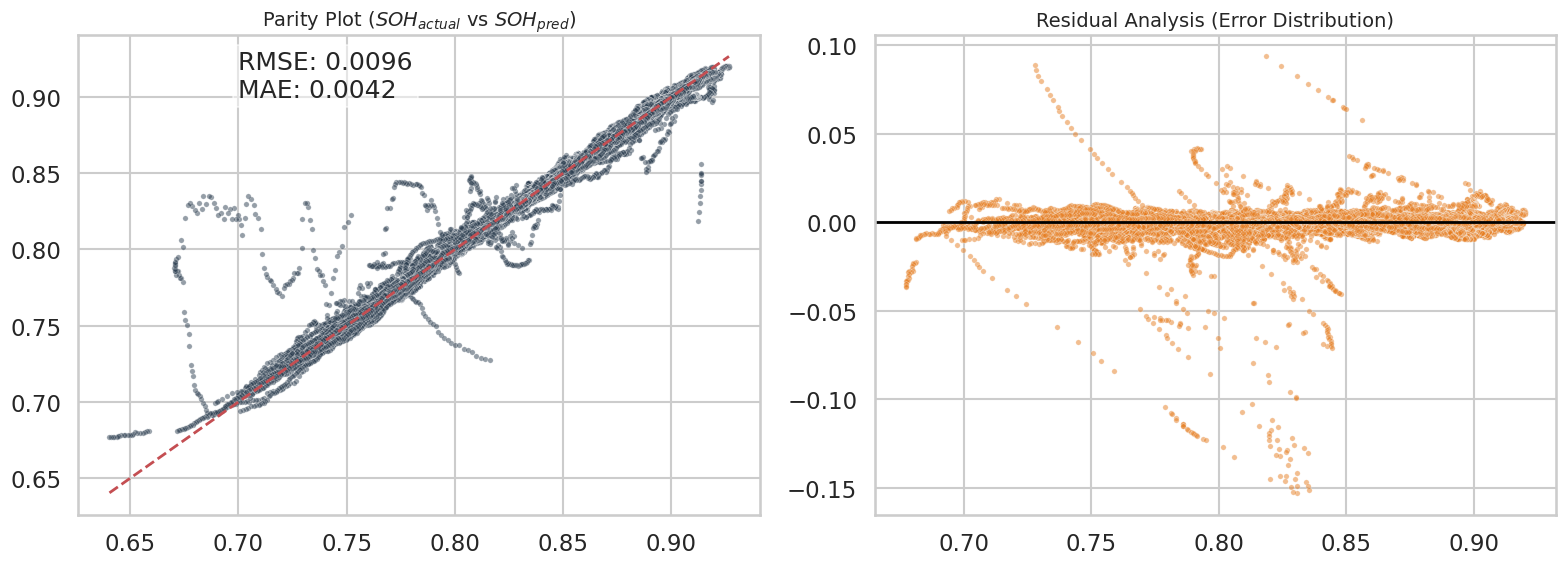

In [11]:
#Set the seaborn theme
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plotted the parity(Real vs Predicted)
sns.scatterplot(x=y_test, y=y_prediction_opt, alpha=0.5, color="#2c3e50", s=15, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(r'Parity Plot ($SOH_{actual}$ vs $SOH_{pred}$)', fontsize=14)


#Plotted the residuals
residuals = y_test - y_prediction_opt
sns.scatterplot(x=y_prediction_opt, y=residuals, alpha=0.5, color="#e67e22", s=15, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='-', lw=2)
axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14)
axes[0].text(0.7, 0.9, f'RMSE: {rmse_opt:.4f}\nMAE: {mae_opt:.4f}', bbox=dict(facecolor='white', alpha=0.5))

#Printed the graph
plt.tight_layout()
plt.show()

8. Hiperparametre optimizasyonu öncesi ve sonrası Random Forest modelinin öznitelik önemlerini karşılaştırdım
(Compared the feature importances of the Random Forest model for before-after hyperparameter optimization).

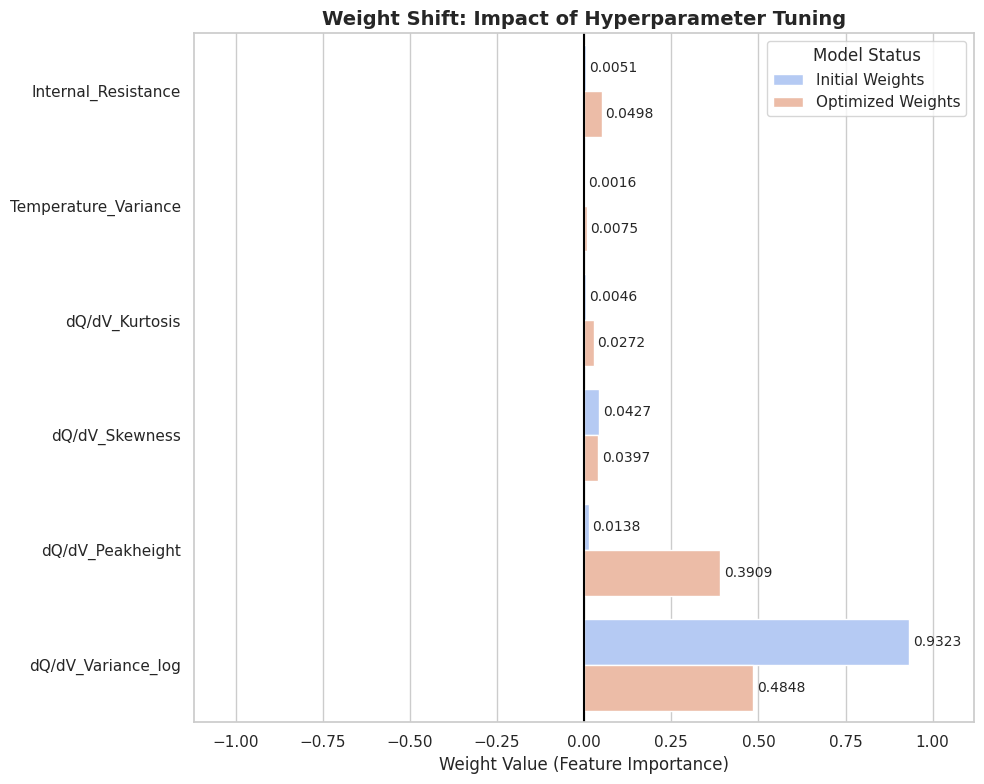

In [12]:
#Defined the feature importance data for features
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Initial Weights': feature_importances,
    'Optimized Weights': opt_feature_importances
}).melt(id_vars='Feature', var_name='Model Status', value_name='Weight Value')

#Defined the size of the plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

#Plotted a bar graph
ax = sns.barplot(
    data=coef_df, 
    y='Feature',      
    x='Weight Value', 
    hue='Model Status', 
    palette='coolwarm'
)

#Adjusted the graph for small values
max_val = coef_df['Weight Value'].abs().max()
plt.xlim(-max_val * 1.2, max_val * 1.2) 

#Set up the title and labels
plt.title('Weight Shift: Impact of Hyperparameter Tuning', fontweight='bold', fontsize=14)
plt.xlabel('Weight Value (Feature Importance)', fontsize=12)
plt.ylabel('') 
plt.axvline(0, color='black', lw=1.5) 

#Wrote the feature importance values on the graph
for p in ax.patches:
    width = p.get_width()
    if abs(width) > 0:
        ax.annotate(f'{width:.4f}', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha = 'center', va = 'center', 
                    xytext = (20 if width > 0 else -20, 0), 
                    textcoords = 'offset points',
                    fontsize=10)

#Printed the graph
plt.tight_layout()
plt.show()

9. Modelin batalyalar özelinde Random Forest modelinin hata oranlarını hesapladım, en yüksek ve en düşük hata oranına sahip piller için model performansını grafiklerle karşılaştırdım
(Calculated the error rates or Random Forest model for individual batteries, compared the model performance with graphics on batteries with highest and lowest error rates).

Rank  | Best Batteries (Low Error)         | Worst Batteries (High Error)  
---------------------------------------------------------------------------
#1    | FastCharge_000012_CH29_st (0.0013) | FastCharge_000041_CH10_st (0.0670)
#2    | FastCharge_000015_CH4_str (0.0014) | FastCharge_000052_CH41_st (0.0485)
#3    | FastCharge_000012_CH23_st (0.0015) | FastCharge_000035_CH12_st (0.0343)
#4    | FastCharge_000006_CH11_st (0.0015) | FastCharge_000017_CH46_st (0.0202)
#5    | FastCharge_000067_CH42_st (0.0015) | FastCharge_000021_CH28_st (0.0154)
#6    | FastCharge_000033_CH14_st (0.0016) | FastCharge_000031_CH9_str (0.0140)
#7    | FastCharge_000066_CH26_st (0.0017) | FastCharge_000024_CH45_st (0.0135)
#8    | FastCharge_000013_CH13_st (0.0017) | FastCharge_000038_CH13_st (0.0127)
#9    | FastCharge_000002_CH2_str (0.0018) | FastCharge_000032_CH22_st (0.0116)
#10   | FastCharge_000039_CH28_st (0.0018) | FastCharge_000068_CH38_st (0.0114)


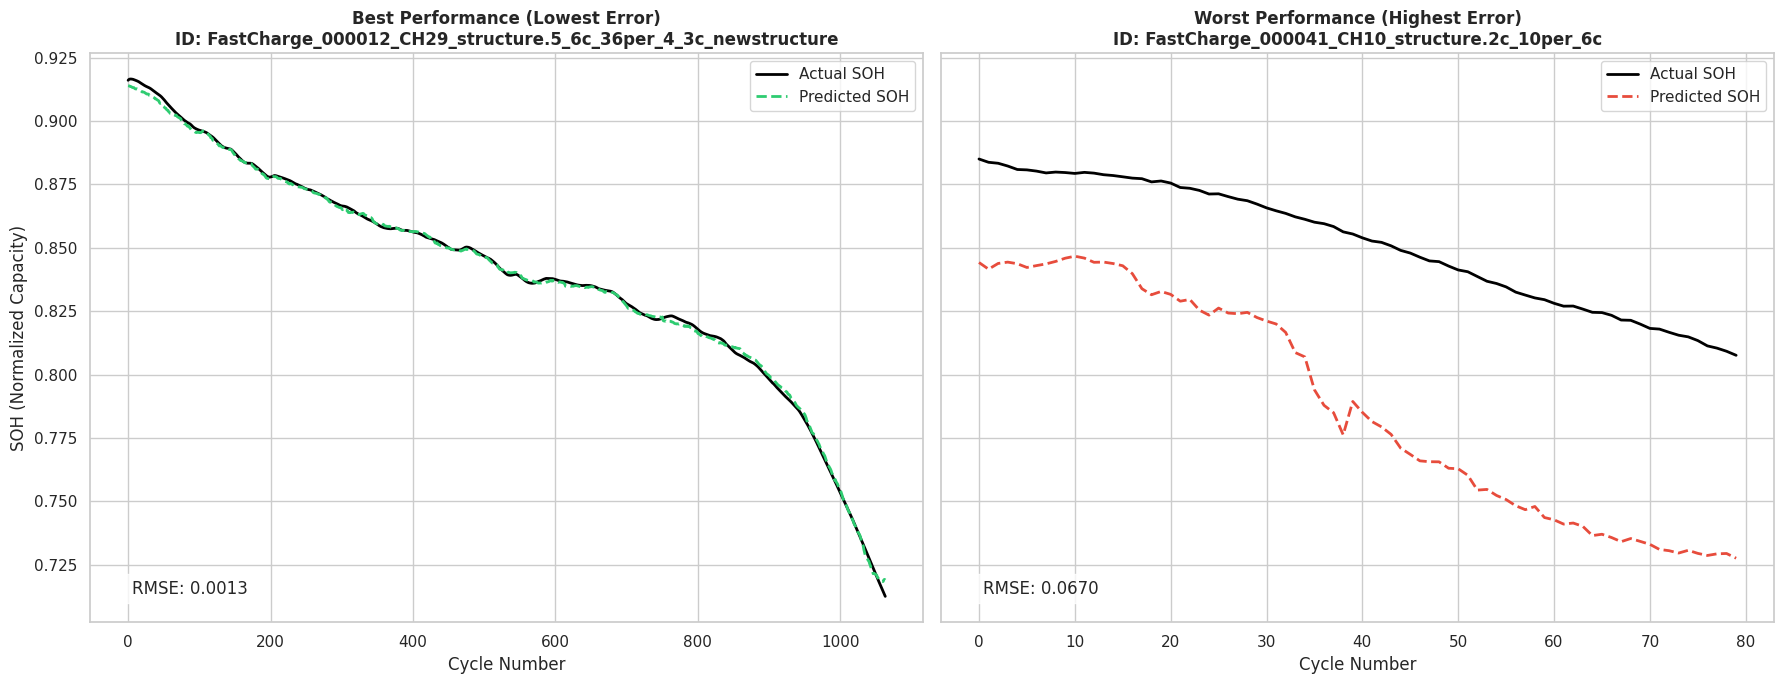

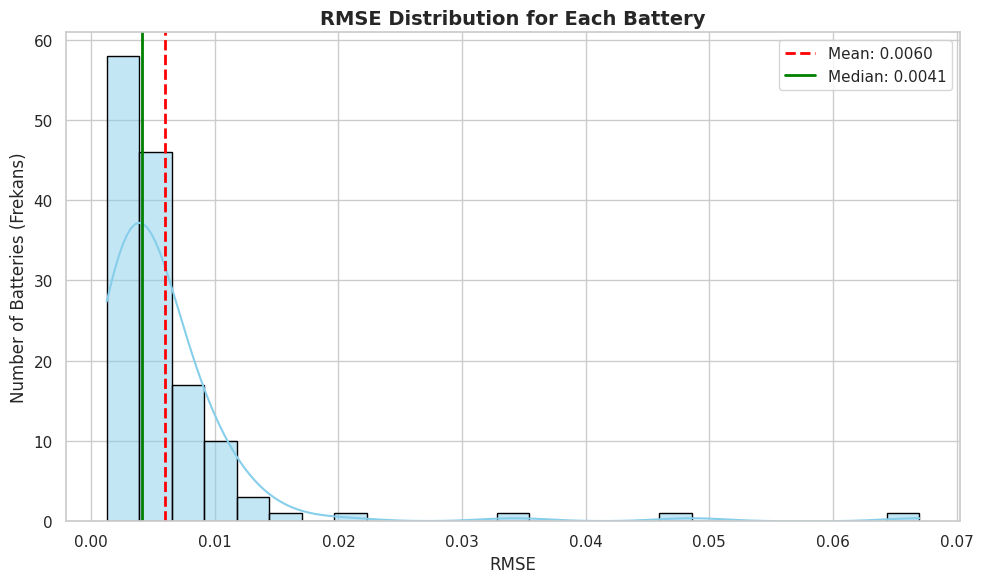

In [13]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined a dictionary to save individual battery errors and results
battery_errors = {}
battery_results = {}

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    batteries = list(h5f.keys())

    #Got the features and target data, and grouped them under same battery name
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combined all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):

        #Defined the Features and Target for train and test datasets
        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built the model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',RandomForestRegressor(random_state=42, n_jobs=-1))
        ])
        
        #Set hyperparameter options for grid search
        param_grid = {
            'model__n_estimators': [200, 300, 500],
            'model__max_depth': [15, 25],
            'model__min_samples_split' : [2],
            'model__min_samples_leaf': [6, 9],
            'model__max_features': ['sqrt']
        }

        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Built another model with optimized hyperparameters and trained it
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model = grid_search.best_estimator_

        #Did the prediction and measured error rates
        y_prediction = model.predict(X_test)
        
        #Found the unique batteries to inspect their error rates 
        test_groups = Groups[test_index]
        unique_batteries = np.unique(test_groups)
        for bat_idx in unique_batteries:
            mask = (test_groups == bat_idx)
            bat_y_true = y_test[mask]
            bat_y_pred = y_prediction[mask]
            bat_rmse = np.sqrt(mean_squared_error(bat_y_true, bat_y_pred))
            bat_name = batteries[bat_idx]
            
            #Saved the values and error rates for plotting
            battery_errors[bat_name] = bat_rmse
            battery_results[bat_name] = {
                'true': bat_y_true,
                'pred': bat_y_pred,
                'rmse': bat_rmse
            }

#Sorted the error rates and got the top 10 and bottom 10 error rates
sorted_errors = sorted(battery_errors.items(), key=lambda item: item[1])
best_10 = sorted_errors[:10]       # En düşük hatalı ilk 10
worst_10 = sorted_errors[-10:][::-1] # En yüksek hatalı son 10 (ters çevrilmiş)

#Printed the results
print(f"{'Rank':<5} | {'Best Batteries (Low Error)':<30}     | {'Worst Batteries (High Error)':<30}")
print("-" * 75)
for i in range(10):
    b_name, b_err = best_10[i]
    w_name, w_err = worst_10[i]
    print(f"#{i+1:<4} | {b_name[:25]:<25} ({b_err:.4f}) | {w_name[:25]:<25} ({w_err:.4f})")

#Found the worst and best resulted batteries
best_bat_name = best_10[0][0]
worst_bat_name = worst_10[0][0]

#Started poltting the results for both of them for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_style("whitegrid")

#Set up the graph,title,axis
for i, (b_name, title, color) in enumerate([
    (best_bat_name, "Best Performance (Lowest Error)", "#2ecc71"),
    (worst_bat_name, "Worst Performance (Highest Error)", "#e74c3c")
]):
    data = battery_results[b_name]
    cycles = range(len(data['true']))
    
    axes[i].plot(cycles, data['true'], label='Actual SOH', color='black', lw=2)
    axes[i].plot(cycles, data['pred'], label='Predicted SOH', color=color, linestyle='--', lw=2)
    
    axes[i].set_title(f"{title}\nID: {b_name}", fontweight='bold')
    axes[i].set_xlabel('Cycle Number')
    axes[i].legend()
    axes[i].text(0.05, 0.05, f"RMSE: {data['rmse']:.4f}", transform=axes[i].transAxes, 
                 bbox=dict(facecolor='white', alpha=0.8))

axes[0].set_ylabel('SOH (Normalized Capacity)')

#Printed the graph
plt.tight_layout()
plt.show()

#Defined an error list
errors_list = list(battery_errors.values())

#Defined the figure and wrote histogram with density curve (KDE)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(errors_list, bins=25, kde=True, color='skyblue', edgecolor='black')

#Added statistical values (Mean and Median)
mean_val = np.mean(errors_list)
median_val = np.median(errors_list)

#Set up the graph,title,axis
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.4f}')

plt.title('RMSE Distribution for Each Battery', fontsize=14, fontweight='bold')
plt.xlabel('RMSE', fontsize=12)
plt.ylabel('Number of Batteries (Frekans)', fontsize=12)
plt.legend()

#Printed the graph
plt.tight_layout()
plt.show()